In [3]:
import os
import glob
import json
import yaml
import shutil
import random
import numpy as np
import pandas as pd
from datetime import datetime
from PIL import Image, ImageDraw
from sklearn.model_selection import train_test_split

In [4]:
save_dir = f"./Processed/"
shutil.rmtree(save_dir, ignore_errors = True)
os.makedirs(save_dir, exist_ok = True)

In [5]:
def stratified_split_by_images(df, val_ratio, random_state=42):
    """
    Split dataset into train/validation using:
    - Image-level grouping (prevents leakage)
    - Size-based stratification (avg bbox area)
    - Class coverage fixing (ensures all classes in validation)
    """
    df = df.copy()

    image_stats = df.groupby("image_id").agg({"bbox_area": ["mean", "count"]})

    image_stats.columns = ["avg_bbox_area", "num_objects"]
    image_stats = image_stats.reset_index()

    image_stats["size_category"] = pd.qcut(
        image_stats["avg_bbox_area"],
        q=3,
        duplicates="drop")
    
    # image_stats["density_category"] = pd.qcut(
    #     image_stats["num_objects"],
    #     q=3,
    #     duplicates="drop")

    train_image_ids, val_image_ids = train_test_split(
        image_stats["image_id"],
        test_size=val_ratio,
        stratify=image_stats["size_category"],
        random_state=random_state
    )

    train_image_ids = set(train_image_ids.values)
    val_image_ids   = set(val_image_ids.values)

    all_classes = set(df["type_id"].unique())

    val_classes = set(df[df["image_id"].isin(val_image_ids)]["type_id"].unique())
    missing_classes = all_classes - val_classes
    
    for type_id in missing_classes:
        candidate_images = df[(df["type_id"] == type_id) & (df["image_id"].isin(train_image_ids))]["image_id"].unique()

        if len(candidate_images) <= 1:
            continue

        np.random.seed(random_state)
        np.random.shuffle(candidate_images)

        num_to_move = min(3, len(candidate_images) - 1)
        selected_images = candidate_images[:num_to_move]

        for img in selected_images:
            train_image_ids.remove(img)
            val_image_ids.add(img)

    train_df = df[df["image_id"].isin(train_image_ids)].copy()
    val_df   = df[df["image_id"].isin(val_image_ids)].copy()

    # any leakage
    assert len(train_image_ids & val_image_ids) == 0, "Data leakage detected!"

    train_classes = set(train_df["type_id"])
    val_classes   = set(val_df["type_id"])

    print("Split Summary")
    print(f"Train Images: {len(train_image_ids)}")
    print(f"Val Images: {len(val_image_ids)}")

    print("\n Class Coverage")
    print(f"Total Classes: {len(all_classes)}")
    print(f"Train Classes: {len(train_classes)}")
    print(f"Val Classes: {len(val_classes)}")

    missing_after = all_classes - val_classes
    if missing_after:
        print(f"Still Missing in Val: {missing_after}")
    else:
        print("All classes present in validation")

    train_df["split"] = "train"
    val_df["split"]= "val"
    return pd.concat([train_df, val_df])

In [6]:
df = pd.read_csv("./Original/train_labels/xview_labels.csv")
split_df= stratified_split_by_images(df, val_ratio=0.15)

Split Summary
Train Images: 707
Val Images: 139

 Class Coverage
Total Classes: 62
Train Classes: 62
Val Classes: 62
All classes present in validation


In [7]:
split_df.head()

,image_id,type_id,xmin,ymin,xmax,ymax,bbox_width,bbox_height,bbox_area,image_height,image_width,split
0,2355.tif,73,2712,1145,2739,1177,34,32,1088,2667.0,2739.0,train
1,2355.tif,73,2720,2233,2739,2288,40,55,2200,2667.0,2739.0,train
2,2355.tif,73,2687,1338,2739,1399,53,61,3233,2667.0,2739.0,train
3,2355.tif,73,2691,1201,2730,1268,39,67,2613,2667.0,2739.0,train
4,2355.tif,73,2671,838,2714,869,43,31,1333,2667.0,2739.0,train


**Image Tiling**

In [8]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image


def get_positions(dim_size, tile_size, stride):
    """
    Generate sliding window positions with minimum padding.

    Ensures:
    - full image coverage
    - consistent overlap
    - avoids heavily padded final tiles
    """

    # image smaller than tile
    if dim_size <= tile_size:
        return [0]

    # regular sliding positions
    positions = list(
        range(
            0,
            dim_size - tile_size + 1,
            stride
        )
    )

    # ensure final boundary coverage
    last_position = dim_size - tile_size

    if positions[-1] != last_position:
        positions.append(last_position)

    return positions


def tile_image(image_arr, tile_size, overlap):
    """
    Generate tiled image patches with padding.
    """

    # image size
    h, w = image_arr.shape[:2]

    # stride
    stride = int(tile_size * (1 - overlap))
    stride = max(1, stride)

    # tile positions
    y_positions = get_positions(h, tile_size, stride)
    x_positions = get_positions(w, tile_size, stride)

    tiles = []

    for y in y_positions:
        for x in x_positions:

            # crop tile
            tile = image_arr[y:y + tile_size, x:x + tile_size]

            orig_h, orig_w = tile.shape[:2]

            # full tile
            if orig_h == tile_size and orig_w == tile_size:
                padded_tile = tile

            # boundary tile
            else:
                pad_y = tile_size - orig_h
                pad_x = tile_size - orig_w

                # safer than reflect for tiny edge cases
                padded_tile = np.pad(
                    tile,
                    ((0, pad_y), (0, pad_x), (0, 0)),
                    mode="edge"
                )

            tiles.append(
                (
                    padded_tile,
                    (x, y),
                    (orig_h, orig_w)
                )
            )

    return tiles


def process_tiling_pipeline(
    df,
    root_dir,
    output_dir,
    tile_size=256,
    overlap=0.20,
    visibility_threshold=0.50,
    keep_empty_prob=0.10
):
    """
    Full tiling pipeline with:
    - safer tiling
    - bbox clipping
    - visibility filtering
    - negative tile retention
    """

    os.makedirs(output_dir, exist_ok=True)

    all_rows = []

    # process image-wise
    for image_name, group in df.groupby("image_id"):

        print(f"Processing: {image_name}")

        # image split
        image_split = group["split"].iloc[0]

        # image path
        img_path = os.path.join(root_dir, image_name)

        # load image
        img = Image.open(img_path).convert("RGB")
        img_arr = np.array(img)

        # generate tiles
        tiles = tile_image(
            img_arr,
            tile_size,
            overlap
        )

        # bbox dataframe
        bbox_df = group[
            ["xmin", "ymin", "xmax", "ymax", "type_id"]
        ].copy()

        # convert numeric types
        bbox_df = bbox_df.astype({
            "xmin": np.float32,
            "ymin": np.float32,
            "xmax": np.float32,
            "ymax": np.float32
        })

        bboxes = bbox_df.values

        for tile, (tile_x, tile_y), _ in tiles:

            # spatial intersection filtering
            mask = ~(
                (bboxes[:, 2] <= tile_x) |
                (bboxes[:, 0] >= tile_x + tile_size) |
                (bboxes[:, 3] <= tile_y) |
                (bboxes[:, 1] >= tile_y + tile_size)
            )

            candidate_boxes = bboxes[mask]

            new_bboxes = []

            # process candidate boxes
            for xmin, ymin, xmax, ymax, type_id in candidate_boxes:

                # original bbox area
                orig_area = (xmax - xmin) * (ymax - ymin)

                # shift bbox
                xmin_new = xmin - tile_x
                ymin_new = ymin - tile_y
                xmax_new = xmax - tile_x
                ymax_new = ymax - tile_y

                # clip bbox
                xmin_new = max(0, xmin_new)
                ymin_new = max(0, ymin_new)
                xmax_new = min(tile_size, xmax_new)
                ymax_new = min(tile_size, ymax_new)

                # invalid bbox
                if xmin_new >= xmax_new or ymin_new >= ymax_new:
                    continue

                # clipped bbox area
                new_area = (
                    (xmax_new - xmin_new) *
                    (ymax_new - ymin_new)
                )

                # visibility filtering
                visibility = new_area / max(orig_area, 1e-6)

                if visibility < visibility_threshold:
                    continue

                # tile image name
                image_id = os.path.splitext(image_name)[0]

                tile_img_id = (
                    f"{image_split}_"
                    f"{image_id}_"
                    f"{tile_x}_{tile_y}.png"
                )

                # append bbox
                new_bboxes.append([
                    image_name,
                    tile_img_id,
                    xmin_new,
                    ymin_new,
                    xmax_new,
                    ymax_new,
                    int(type_id),
                    image_split
                ])

            # retain some empty tiles
            if len(new_bboxes) == 0:

                if random.random() > keep_empty_prob:
                    continue

                # save empty tile
                image_id = os.path.splitext(image_name)[0]

                tile_img_id = (
                    f"{image_split}_"
                    f"{image_id}_"
                    f"{tile_x}_{tile_y}.png"
                )

            # save directory
            save_dir = os.path.join(
                output_dir,
                image_split
            )

            os.makedirs(save_dir, exist_ok=True)

            # save tile
            tile_img = Image.fromarray(tile)

            tile_img.save(
                os.path.join(save_dir, tile_img_id)
            )

            # append labels
            all_rows.extend(new_bboxes)

    # output dataframe
    new_df = pd.DataFrame(
        all_rows,
        columns=[
            "image_id",
            "tile_image_id",
            "xmin",
            "ymin",
            "xmax",
            "ymax",
            "type_id",
            "split"
        ]
    )

    return new_df


# =========================
# RUN PIPELINE
# =========================

tiled_df = process_tiling_pipeline(
    df=split_df,
    root_dir="./Original/train_images",
    output_dir="./Processed/images",
    tile_size=256,
    overlap=0.30,
    visibility_threshold=0.50,
    keep_empty_prob=0.10
)

Processing: 10.tif
Processing: 100.tif
Processing: 102.tif
Processing: 1036.tif
Processing: 1037.tif
Processing: 104.tif
Processing: 1042.tif
Processing: 1044.tif
Processing: 1046.tif
Processing: 1048.tif
Processing: 1049.tif
Processing: 105.tif
Processing: 1050.tif
Processing: 1051.tif
Processing: 1052.tif
Processing: 1053.tif
Processing: 1056.tif
Processing: 1058.tif
Processing: 106.tif
Processing: 1061.tif
Processing: 1063.tif
Processing: 1065.tif
Processing: 1067.tif
Processing: 1068.tif
Processing: 107.tif
Processing: 1070.tif
Processing: 1072.tif
Processing: 1076.tif
Processing: 1077.tif
Processing: 1079.tif
Processing: 1080.tif
Processing: 1081.tif
Processing: 1084.tif
Processing: 1085.tif
Processing: 1086.tif
Processing: 1087.tif
Processing: 1088.tif
Processing: 1089.tif
Processing: 109.tif
Processing: 1090.tif
Processing: 1091.tif
Processing: 1092.tif
Processing: 1094.tif
Processing: 1095.tif
Processing: 110.tif
Processing: 1104.tif
Processing: 1106.tif
Processing: 1109.tif
Pr

In [10]:
def fetch_id2label(txt_path):
    id2label= {}
    with open(txt_path, "r") as f:
        for line in f:
            txt= line.strip().split(':')
            id2label[int(txt[0])] = txt[1]
    return id2label

def fetch_id2clsmap(df):
    id2clsmap= {}
    count= 0
    for type_id in np.unique(df.type_id):
        id2clsmap[type_id] = count
        count+=1
    return id2clsmap


txt_file= "../dataset/Original/xview_class_labels.txt"
id2label= fetch_id2label(txt_file)
id2clsmap= fetch_id2clsmap(tiled_df)
tiled_df["label"]= tiled_df["type_id"].map(id2clsmap)
tiled_df["category"]= tiled_df["type_id"].map(id2label)

In [11]:
# result = (
#     tiled_df[['label', 'category']]
#     .drop_duplicates()
#     .sort_values(by='label')
# )

# label2cls= dict(result.values)

**Remove Outlier BBoxes**

In [13]:
tiled_df= tiled_df[~tiled_df['category'].isna()]

In [9]:
# def smart_filter_v2(df, tile_w, tile_h, max_area, margin, min_wh):
#     w = df['xmax'] - df['xmin']
#     h = df['ymax'] - df['ymin']
#     area = w * h

#     df = df.copy()  # avoid modifying original
#     df['area'] = area

#     inside = (
#         (df['xmin'] >= margin) &
#         (df['ymin'] >= margin) &
#         (df['xmax'] <= tile_w - margin) &
#         (df['ymax'] <= tile_h - margin)
#     )

#     size_ok = (w >= min_wh) & (h >= min_wh)

#     # enforce max_area globally
#     keep = (inside | size_ok) & (area <= max_area)

#     return df[keep].reset_index(drop=True)

In [10]:
#tiled_df_updated= smart_filter_v2(tiled_df, tile_w=700, tile_h=700, max_area=50000, margin=40, min_wh=10)
#tiled_df_updated

In [14]:
tiled_df.to_csv("./Processed/annotations.csv", index=False)

**Export Utils**

In [17]:
def export_to_yolo(annot_df, image_root, output_dir,tile_size):
    """
    Export YOLO labels including empty label files.
    """

    os.makedirs(output_dir, exist_ok=True)

    # annotation lookup
    grouped = {
        name: group
        for name, group in annot_df.groupby("tile_image_id")
    }

    # iterate through splits
    for split in os.listdir(image_root):

        split_img_dir = os.path.join(image_root, split)

        if not os.path.isdir(split_img_dir):
            continue

        split_label_dir = os.path.join(output_dir, split)
        os.makedirs(split_label_dir, exist_ok=True)

        # all tile images
        image_paths = glob.glob(
            os.path.join(split_img_dir, "*.png")
        )

        for img_path in image_paths:

            tile_name = os.path.basename(img_path)

            txt_name = os.path.splitext(tile_name)[0] + ".txt"

            txt_path = os.path.join(
                split_label_dir,
                txt_name
            )

            # EMPTY TILE
            if tile_name not in grouped:

                # create empty txt
                open(txt_path, "w").close()
                continue

            # annotated tile
            group = grouped[tile_name]

            bboxes = group[
                ["xmin", "ymin", "xmax", "ymax"]
            ].values.astype(np.float32)

            class_ids = group["label"].values.astype(int)

            # convert to YOLO
            x_center = (
                (bboxes[:, 0] + bboxes[:, 2]) / 2.0
            )

            y_center = (
                (bboxes[:, 1] + bboxes[:, 3]) / 2.0
            )

            width = (
                bboxes[:, 2] - bboxes[:, 0]
            )

            height = (
                bboxes[:, 3] - bboxes[:, 1]
            )

            # normalize
            x_center /= tile_size
            y_center /= tile_size
            width /= tile_size
            height /= tile_size

            # write labels
            with open(txt_path, "w") as f:

                for cls, xc, yc, w, h in zip(
                    class_ids,
                    x_center,
                    y_center,
                    width,
                    height
                ):

                    f.write(
                        f"{cls} "
                        f"{xc:.6f} "
                        f"{yc:.6f} "
                        f"{w:.6f} "
                        f"{h:.6f}\n"
                    )

    print("YOLO labels exported successfully.")


def export_to_coco(annot_df, output_dir, tile_size):
    os.makedirs(output_dir, exist_ok=True)
    
    coco_json= {
        "info": {
        "description": "xView Satellite Imagery Dataset (Tiled)",
        "date_created": datetime.now().isoformat(),
        },
        "images": [],
        "annotations": [],
        "categories": []
    }

    # store categories metadata
    categories= annot_df[["label", "category"]].drop_duplicates().sort_values("label")
    for row in categories.itertuples(index=False):
        coco_json["categories"].append({
            "id": int(row.label),
            "name": row.category,
            "supercategory": "none"
        })

    # store images metadata
    image2id= {}
    images= []
    unique_tiles = annot_df["tile_image_id"].unique()
    for i, tile_image_id in enumerate(unique_tiles):
        images.append({"id": i,
                       "file_name": tile_image_id,
                       "width": tile_size,
                       "height": tile_size
                      })
        image2id[tile_image_id]= i

    coco_json["images"]= images
    
    # store annotations metadata
    annot_id= 0
    annotations = []
    for row in annot_df.itertuples(index=False):
        xmin = row.xmin
        ymin = row.ymin
        xmax = row.xmax
        ymax = row.ymax

        width = xmax - xmin
        height = ymax - ymin
        if width <= 0 or height <= 0:
            continue
        area = width * height
        
        tile_image_id= row.tile_image_id
        category_id= row.label

        annotations.append({"id": annot_id,
                            "image_id": image2id[tile_image_id],
                            "category_id": int(category_id),
                            "bbox": [xmin, ymin, width, height],
                            "area": area,
                            "segmentation": [],
                            "iscrowd": 0
                           })
        annot_id+=1
        
    coco_json["annotations"]= annotations    
    
    # 5. Export to JSON
    output_path= os.path.join(output_dir, "annotations.json")
    with open(output_path, 'w') as f:
        json.dump(coco_json, f, indent=4)
    
    print("COCO JSON exported successfully.")
    return coco_json



In [19]:
export_to_yolo(tiled_df, image_root= "./Processed/images", output_dir= "./Processed/labels", tile_size= 256)
#export_to_coco(tiled_df, output_dir= "../Dataset/Processed/", tile_size=512)

YOLO labels exported successfully.


**Filter Images & Labels**

In [20]:
import os

def clean_yolo_dataset(root_dir):
    """
    Cleans YOLO dataset by:
    1. Ensuring image-label pairs exist
    2. Removing images without labels
    3. Removing labels without images
    4. Removing empty label files and their corresponding images

    Args:
        root_dir (str): Path to 'Processed' directory
    """

    splits = ['train', 'val']
    image_ext = '.png'

    for split in splits:
        print(f"\nProcessing split: {split}")

        img_dir = os.path.join(root_dir, 'images', split)
        lbl_dir = os.path.join(root_dir, 'labels', split)

        if not os.path.exists(img_dir) or not os.path.exists(lbl_dir):
            print(f"Skipping {split} (missing folders)")
            continue

        img_files = set(os.listdir(img_dir))
        lbl_files = set(os.listdir(lbl_dir))

        # Convert to base names (without extension)
        img_ids = set(os.path.splitext(f)[0] for f in img_files if f.endswith(image_ext))
        lbl_ids = set(os.path.splitext(f)[0] for f in lbl_files if f.endswith('.txt'))

        # 1️⃣ Remove images without labels
        imgs_without_labels = img_ids - lbl_ids
        for img_id in imgs_without_labels:
            img_path = os.path.join(img_dir, img_id + image_ext)
            if os.path.exists(img_path):
                os.remove(img_path)

        # 2️⃣ Remove labels without images
        labels_without_imgs = lbl_ids - img_ids
        for lbl_id in labels_without_imgs:
            lbl_path = os.path.join(lbl_dir, lbl_id + '.txt')
            if os.path.exists(lbl_path):
                os.remove(lbl_path)

        # Refresh after cleanup
        valid_ids = img_ids & lbl_ids

        # 3️⃣ Remove empty label files + corresponding images
        removed_empty = 0

        for file_id in valid_ids:
            lbl_path = os.path.join(lbl_dir, file_id + '.txt')
            img_path = os.path.join(img_dir, file_id + image_ext)

            try:
                # Check if file is empty or only whitespace
                if os.path.getsize(lbl_path) == 0:
                    is_empty = True
                else:
                    with open(lbl_path, 'r') as f:
                        content = f.read().strip()
                        is_empty = (content == "")

                if is_empty:
                    if os.path.exists(lbl_path):
                        os.remove(lbl_path)
                    if os.path.exists(img_path):
                        os.remove(img_path)
                    removed_empty += 1

            except Exception as e:
                print(f"Error processing {file_id}: {e}")

        print(f"Removed {len(imgs_without_labels)} images without labels")
        print(f"Removed {len(labels_without_imgs)} labels without images")
        print(f"Removed {removed_empty} empty label-image pairs")

    print("\n✅ Dataset cleanup completed.")

In [127]:
clean_yolo_dataset(root_dir= "./Processed")


Processing split: train
Removed 165 images without labels
Removed 0 labels without images
Removed 0 empty label-image pairs

Processing split: val
Removed 30 images without labels
Removed 0 labels without images
Removed 0 empty label-image pairs

✅ Dataset cleanup completed.


**Visualize**

In [21]:
def show_image(image_path, df, class_labels):
    df= df.copy()
    df["category"]= df["type_id"].map(class_labels)
    
    # load image
    image= Image.open(image_path)
    draw = ImageDraw.Draw(image)
    
    image_id= image_path.split("/")[-1]
    bbox_df= df[df["tile_image_id"] == image_id]

    for idx, row in bbox_df.iterrows():
        xmin= row["xmin"]
        ymin= row["ymin"]
        xmax= row["xmax"]
        ymax= row["ymax"]
        type_id= row["type_id"]

        draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=2)
        draw.text((xmin, ymin), str(type_id) , fill="yellow")
        
    return image


def visualize_yolo_annotation(image_dir, label_dir, image_path=None):

    #random image if not provided
    if image_path is None:
        images = [f for f in os.listdir(image_dir) if f.endswith((".png", ".jpg", ".jpeg"))]
        image_name = random.choice(images)
        image_path = os.path.join(image_dir, image_name)
    else:
        image_name = os.path.basename(image_path)

    print(image_name)
    img = Image.open(image_path).convert("RGB")
    w, h = img.size

    draw = ImageDraw.Draw(img)

    label_name = os.path.splitext(image_name)[0] + ".txt"
    label_path = os.path.join(label_dir, label_name)

    if not os.path.exists(label_path):
        print(f"No label file found for {image_name}")
        return img

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        cls, xc, yc, bw, bh = map(float, line.strip().split())

        xc *= w
        yc *= h
        bw *= w
        bh *= h

        xmin = int(xc - bw / 2)
        ymin = int(yc - bh / 2)
        xmax = int(xc + bw / 2)
        ymax = int(yc + bh / 2)

        # Draw rectangle
        draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=2)

        # Draw class id
        draw.text((xmin, ymin), str(int(cls)), fill="yellow")

    return img

def visualize_coco_annotation(image_dir, coco_json_path, image_id=None):

    with open(coco_json_path, "r") as f:
        coco = json.load(f)

    images = coco["images"]
    annotations = coco["annotations"]

    if image_id is None:
        img_info = random.choice(images)
    else:
        img_info = next(img for img in images if img["id"] == image_id)

    file_name = img_info["file_name"]
    image_id = img_info["id"]

    image_path = os.path.join(image_dir, file_name)
    img = Image.open(image_path).convert("RGB")

    draw = ImageDraw.Draw(img)

    anns = [ann for ann in annotations if ann["image_id"] == image_id]

    for ann in anns:
        x, y, w, h = ann["bbox"]

        xmin = int(x)
        ymin = int(y)
        xmax = int(x + w)
        ymax = int(y + h)

        draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=2)

        draw.text((xmin, ymin), str(ann["category_id"]), fill="yellow")

    return img

train_1459_358_2864.png


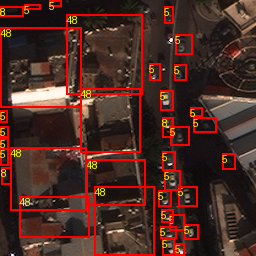

In [30]:
# visualize
visualize_yolo_annotation(image_dir= "./Processed/images/train", label_dir="./Processed/labels/train")
#visualize_coco_annotation(image_dir= "../dataset/Processed/images/train", coco_json_path="../dataset/Processed/labels/train")

In [29]:
import os

img_dir = "Processed/images/train"
lbl_dir = "Processed/labels/train"

missing = []
for img in os.listdir(img_dir):
    name = os.path.splitext(img)[0]
    if not os.path.exists(os.path.join(lbl_dir, name + ".txt")):
        missing.append(name)

print("Missing labels:", len(missing))

Missing labels: 0
